In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [60]:
df = pd.read_csv("Flight_Passenger_Dataset.csv")

In [61]:
print("Dataset shape:",df.shape)
print(df.columns)

Dataset shape: (500, 16)
Index(['Passenger_ID', 'Passenger_Name', 'Passenger_Age', 'Gender', 'Airline',
       'Flight_Number', 'Flight_Date', 'Start_City', 'Destination_City',
       'Scheduled_Departure', 'Actual_Departure', 'Scheduled_Arrival',
       'Actual_Arrival', 'Ticket_Price', 'Class', 'Seat_Number'],
      dtype='str')


In [62]:
df.head()

,Passenger_ID,Passenger_Name,Passenger_Age,Gender,Airline,Flight_Number,Flight_Date,Start_City,Destination_City,Scheduled_Departure,Actual_Departure,Scheduled_Arrival,Actual_Arrival,Ticket_Price,Class,Seat_Number
0,P0001,Kritika Kumar,27,Female,IndiGo,6.00E+169,01-01-2026,Lucknow,Jaipur,01-01-2026 06:30,01-01-2026 06:34,01-01-2026 07:41,01-01-2026 07:43,13270,Business,4D
1,P0002,Sneha Kumar,57,Female,Alliance Air,9I735,01-01-2026,Kochi,Varanasi,01-01-2026 06:35,01-01-2026 06:37,01-01-2026 09:36,01-01-2026 09:50,36670,Business,2C
2,P0003,Deepak Banerjee,34,Male,Air India Express,IX302,02-01-2026,Madurai,Guwahati,02-01-2026 11:15,02-01-2026 11:24,02-01-2026 14:43,02-01-2026 14:44,17470,Economy,44B
3,P0004,Rohit Krishnan,31,Male,Air India,AI968,02-01-2026,Pune,Madurai,02-01-2026 12:35,02-01-2026 12:41,02-01-2026 14:32,02-01-2026 14:36,10020,Economy,33F
4,P0005,Nisha Joshi,45,Female,IndiGo,6E519,02-01-2026,Madurai,Delhi,02-01-2026 12:40,02-01-2026 12:48,02-01-2026 15:54,02-01-2026 16:03,17860,Economy,19A


In [63]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Passenger_ID         500 non-null    str  
 1   Passenger_Name       500 non-null    str  
 2   Passenger_Age        500 non-null    int64
 3   Gender               500 non-null    str  
 4   Airline              500 non-null    str  
 5   Flight_Number        500 non-null    str  
 6   Flight_Date          500 non-null    str  
 7   Start_City           500 non-null    str  
 8   Destination_City     500 non-null    str  
 9   Scheduled_Departure  500 non-null    str  
 10  Actual_Departure     500 non-null    str  
 11  Scheduled_Arrival    500 non-null    str  
 12  Actual_Arrival       500 non-null    str  
 13  Ticket_Price         500 non-null    int64
 14  Class                500 non-null    str  
 15  Seat_Number          500 non-null    str  
dtypes: int64(2), str(14)
memory usage: 62

,Passenger_Age,Ticket_Price
count,500.000000,500.000000
mean,39.352000,14440.660000
std,17.635479,10505.370101
min,5.000000,2500.000000
25%,25.000000,7852.500000
50%,39.000000,12055.000000
75%,53.000000,17472.500000
max,79.000000,68860.000000


In [64]:
df.isnull().sum()

Passenger_ID           0
Passenger_Name         0
Passenger_Age          0
Gender                 0
Airline                0
Flight_Number          0
Flight_Date            0
Start_City             0
Destination_City       0
Scheduled_Departure    0
Actual_Departure       0
Scheduled_Arrival      0
Actual_Arrival         0
Ticket_Price           0
Class                  0
Seat_Number            0
dtype: int64

In [65]:
print("Unique Airlines:", df["Airline"].nunique())

print("Unique Start Cities:", df["Start_City"].nunique())

print("Unique Destination Cities:", df["Destination_City"].nunique())

Unique Airlines: 6
Unique Start Cities: 30
Unique Destination Cities: 30


In [66]:
df["Airline"].value_counts()

Airline
IndiGo               156
Air India            111
SpiceJet              77
Air India Express     69
Akasa Air             52
Alliance Air          35
Name: count, dtype: int64

In [67]:
df["Gender"].value_counts()

Gender
Female    253
Male      247
Name: count, dtype: int64

In [68]:
df["Class"].value_counts()

Class
Economy            337
Premium Economy     86
Business            77
Name: count, dtype: int64

In [69]:
print("Duplicate Rows:",df.duplicated().sum())

Duplicate Rows: 0


In [70]:
print(df.columns)

Index(['Passenger_ID', 'Passenger_Name', 'Passenger_Age', 'Gender', 'Airline',
       'Flight_Number', 'Flight_Date', 'Start_City', 'Destination_City',
       'Scheduled_Departure', 'Actual_Departure', 'Scheduled_Arrival',
       'Actual_Arrival', 'Ticket_Price', 'Class', 'Seat_Number'],
      dtype='str')


In [71]:
df["Flight_Date"] = pd.to_datetime(df["Flight_Date"],
dayfirst=True
)

In [72]:
df["Scheduled_Departure"] = pd.to_datetime(
    df["Scheduled_Departure"],
    dayfirst=True
)

df["Actual_Departure"] = pd.to_datetime(
    df["Actual_Departure"],
    dayfirst=True
)

df["Scheduled_Arrival"] = pd.to_datetime(
    df["Scheduled_Arrival"],
    dayfirst=True
)

df["Actual_Arrival"] = pd.to_datetime(
    df["Actual_Arrival"],
    dayfirst=True
)

In [73]:
print(df.loc[0])

Passenger_ID                         P0001
Passenger_Name               Kritika Kumar
Passenger_Age                           27
Gender                              Female
Airline                             IndiGo
Flight_Number                    6.00E+169
Flight_Date            2026-01-01 00:00:00
Start_City                         Lucknow
Destination_City                    Jaipur
Scheduled_Departure    2026-01-01 06:30:00
Actual_Departure       2026-01-01 06:34:00
Scheduled_Arrival      2026-01-01 07:41:00
Actual_Arrival         2026-01-01 07:43:00
Ticket_Price                         13270
Class                             Business
Seat_Number                             4D
Name: 0, dtype: object


In [74]:
df["Flight_Date"] = pd.to_datetime(df["Flight_Date"])

df["Scheduled_Departure"] = pd.to_datetime(df["Scheduled_Departure"])

df["Actual_Departure"] = pd.to_datetime(df["Actual_Departure"])

df["Scheduled_Arrival"] = pd.to_datetime(df["Scheduled_Arrival"])

df["Actual_Arrival"] = pd.to_datetime(df["Actual_Arrival"])

In [75]:
print(df.dtypes)

Passenger_ID                      str
Passenger_Name                    str
Passenger_Age                   int64
Gender                            str
Airline                           str
Flight_Number                     str
Flight_Date            datetime64[us]
Start_City                        str
Destination_City                  str
Scheduled_Departure    datetime64[us]
Actual_Departure       datetime64[us]
Scheduled_Arrival      datetime64[us]
Actual_Arrival         datetime64[us]
Ticket_Price                    int64
Class                             str
Seat_Number                       str
dtype: object


In [76]:
df["Flight_Duration"] = (
    df["Actual_Arrival"] -
    df["Actual_Departure"]
).dt.total_seconds() / 60

In [77]:
df[["Actual_Departure",
    "Actual_Arrival",
    "Flight_Duration"]].head()

,Actual_Departure,Actual_Arrival,Flight_Duration
0,2026-01-01 06:34:00,2026-01-01 07:43:00,69.0
1,2026-01-01 06:37:00,2026-01-01 09:50:00,193.0
2,2026-01-02 11:24:00,2026-01-02 14:44:00,200.0
3,2026-01-02 12:41:00,2026-01-02 14:36:00,115.0
4,2026-01-02 12:48:00,2026-01-02 16:03:00,195.0


In [78]:
df["Departure_Delay"] = (
    df["Actual_Departure"] -
    df["Scheduled_Departure"]
).dt.total_seconds() / 60

In [79]:
df[["Scheduled_Departure",
    "Actual_Departure",
    "Departure_Delay"]].head()

,Scheduled_Departure,Actual_Departure,Departure_Delay
0,2026-01-01 06:30:00,2026-01-01 06:34:00,4.0
1,2026-01-01 06:35:00,2026-01-01 06:37:00,2.0
2,2026-01-02 11:15:00,2026-01-02 11:24:00,9.0
3,2026-01-02 12:35:00,2026-01-02 12:41:00,6.0
4,2026-01-02 12:40:00,2026-01-02 12:48:00,8.0


In [80]:
df["Arrival_Delay"] = (
    df["Actual_Arrival"] -
    df["Scheduled_Arrival"]
).dt.total_seconds() / 60

In [81]:
df[["Scheduled_Arrival",
    "Actual_Arrival",
    "Arrival_Delay"]].head()

,Scheduled_Arrival,Actual_Arrival,Arrival_Delay
0,2026-01-01 07:41:00,2026-01-01 07:43:00,2.0
1,2026-01-01 09:36:00,2026-01-01 09:50:00,14.0
2,2026-01-02 14:43:00,2026-01-02 14:44:00,1.0
3,2026-01-02 14:32:00,2026-01-02 14:36:00,4.0
4,2026-01-02 15:54:00,2026-01-02 16:03:00,9.0


In [82]:
df.head()

,Passenger_ID,Passenger_Name,Passenger_Age,Gender,Airline,Flight_Number,Flight_Date,Start_City,Destination_City,Scheduled_Departure,Actual_Departure,Scheduled_Arrival,Actual_Arrival,Ticket_Price,Class,Seat_Number,Flight_Duration,Departure_Delay,Arrival_Delay
0,P0001,Kritika Kumar,27,Female,IndiGo,6.00E+169,2026-01-01,Lucknow,Jaipur,2026-01-01 06:30:00,2026-01-01 06:34:00,2026-01-01 07:41:00,2026-01-01 07:43:00,13270,Business,4D,69.0,4.0,2.0
1,P0002,Sneha Kumar,57,Female,Alliance Air,9I735,2026-01-01,Kochi,Varanasi,2026-01-01 06:35:00,2026-01-01 06:37:00,2026-01-01 09:36:00,2026-01-01 09:50:00,36670,Business,2C,193.0,2.0,14.0
2,P0003,Deepak Banerjee,34,Male,Air India Express,IX302,2026-01-02,Madurai,Guwahati,2026-01-02 11:15:00,2026-01-02 11:24:00,2026-01-02 14:43:00,2026-01-02 14:44:00,17470,Economy,44B,200.0,9.0,1.0
3,P0004,Rohit Krishnan,31,Male,Air India,AI968,2026-01-02,Pune,Madurai,2026-01-02 12:35:00,2026-01-02 12:41:00,2026-01-02 14:32:00,2026-01-02 14:36:00,10020,Economy,33F,115.0,6.0,4.0
4,P0005,Nisha Joshi,45,Female,IndiGo,6E519,2026-01-02,Madurai,Delhi,2026-01-02 12:40:00,2026-01-02 12:48:00,2026-01-02 15:54:00,2026-01-02 16:03:00,17860,Economy,19A,195.0,8.0,9.0


In [83]:
df.to_csv("Flight_Passenger_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [84]:
ages = np.array(df["Passenger_Age"])

print("Average Age :", np.mean(ages))
print("Youngest Passenger :", np.min(ages))
print("Oldest Passenger :", np.max(ages))
print("Median Age :", np.median(ages))
print("Standard Deviation :", np.std(ages))

Average Age : 39.352
Youngest Passenger : 5
Oldest Passenger : 79
Median Age : 39.0
Standard Deviation : 17.617834600199878


In [85]:
prices = np.array(df["Ticket_Price"])

print("Average Ticket Price :", np.mean(prices))
print("Maximum Ticket Price :", np.max(prices))
print("Minimum Ticket Price :", np.min(prices))
print("Median Ticket Price :", np.median(prices))
print("Variance :", np.var(prices))
print("Standard Deviation :", np.std(prices))

Average Ticket Price : 14440.66
Maximum Ticket Price : 68860
Minimum Ticket Price : 2500
Median Ticket Price : 12055.0
Variance : 110142075.3644
Standard Deviation : 10494.85947330406


In [86]:
total_revenue = np.sum(prices)
print("Total Revenue :", total_revenue)

Total Revenue : 7220330


In [87]:
duration = np.array(df["Flight_Duration"])

print("Average Flight Duration :", np.mean(duration))
print("Shortest Flight :", np.min(duration))
print("Longest Flight :", np.max(duration))

Average Flight Duration : 124.49
Shortest Flight : 38.0
Longest Flight : 256.0


In [88]:
departure_delay = np.array(df["Departure_Delay"])

print("Average Departure Delay :", np.mean(departure_delay))
print("Maximum Delay :", np.max(departure_delay))
print("Minimum Delay :", np.min(departure_delay))

Average Departure Delay : 28.054
Maximum Delay : 212.0
Minimum Delay : -17.0


In [89]:
arrival_delay = np.array(df["Arrival_Delay"])

print("Average Arrival Delay :", np.mean(arrival_delay))
print("Maximum Arrival Delay :", np.max(arrival_delay))
print("Minimum Arrival Delay :", np.min(arrival_delay))

Average Arrival Delay : 32.31
Maximum Arrival Delay : 215.0
Minimum Arrival Delay : -21.0


In [90]:
print("25th Percentile :", np.percentile(prices, 25))
print("50th Percentile (Median) :", np.percentile(prices, 50))
print("75th Percentile :", np.percentile(prices, 75))

25th Percentile : 7852.5
50th Percentile (Median) : 12055.0
75th Percentile : 17472.5


In [91]:
df["Price_Category"] = np.where(
    df["Ticket_Price"] >= np.mean(prices),
    "High Price",
    "Low Price"
)

df[["Ticket_Price", "Price_Category"]].head()

,Ticket_Price,Price_Category
0,13270,Low Price
1,36670,High Price
2,17470,High Price
3,10020,Low Price
4,17860,High Price


In [92]:
conditions = [
    df["Passenger_Age"] < 18,
    (df["Passenger_Age"] >= 18) & (df["Passenger_Age"] < 60),
    df["Passenger_Age"] >= 60
]

choices = [
    "Child",
    "Adult",
    "Senior"
]

df["Age_Group"] = np.select(conditions, choices, default="Unknown")
df[["Passenger_Age", "Age_Group"]].head()

,Passenger_Age,Age_Group
0,27,Adult
1,57,Adult
2,34,Adult
3,31,Adult
4,45,Adult


In [93]:
sample = df.sample(5)
print(sample)

    Passenger_ID    Passenger_Name  Passenger_Age  Gender            Airline  \
286        P0287       Deepika Rao             23  Female             IndiGo   
9          P0010      Geeta Pandey             50  Female  Air India Express   
117        P0118      Ritu Rathore             59  Female          Air India   
349        P0350      Sanjay Reddy             19    Male             IndiGo   
472        P0473  Radhika Banerjee             63  Female          Akasa Air   

    Flight_Number Flight_Date Start_City Destination_City Scheduled_Departure  \
286         6E834  2026-04-17      Surat        Bengaluru 2026-04-17 15:55:00   
9           IX888  2026-01-04      Delhi          Chennai 2026-01-04 13:15:00   
117         AI317  2026-02-10    Madurai    Visakhapatnam 2026-02-10 22:25:00   
349         6E471  2026-05-11      Delhi      Bhubaneswar 2026-05-11 10:30:00   
472         QP570  2026-06-23     Jaipur             Pune 2026-06-23 21:45:00   

     ...   Scheduled_Arrival    

In [94]:
print("=" * 50)
print("Flight Passenger Dataset Summary")
print("=" * 50)

print("Total Passengers :", len(df))
print("Average Age :", np.mean(ages))
print("Average Ticket Price :", np.mean(prices))
print("Total Revenue :", np.sum(prices))
print("Average Flight Duration :", np.mean(df["Flight_Duration"]))

print("=" * 50)

Flight Passenger Dataset Summary
Total Passengers : 500
Average Age : 39.352
Average Ticket Price : 14440.66
Total Revenue : 7220330
Average Flight Duration : 124.49


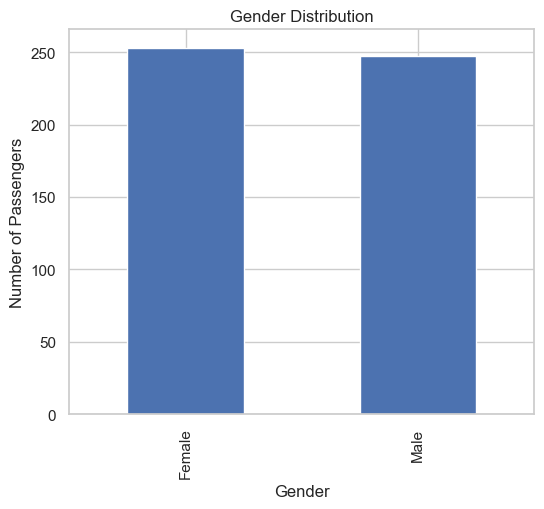

In [95]:
plt.figure(figsize=(6,5))
df["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

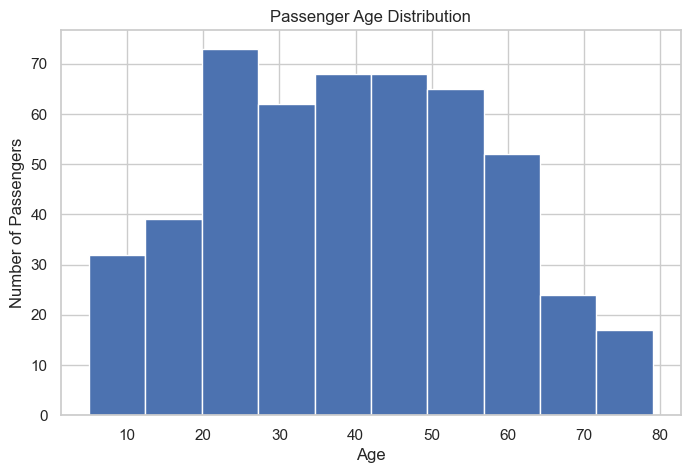

In [96]:
plt.figure(figsize=(8,5))
plt.hist(df["Passenger_Age"], bins=10)
plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()

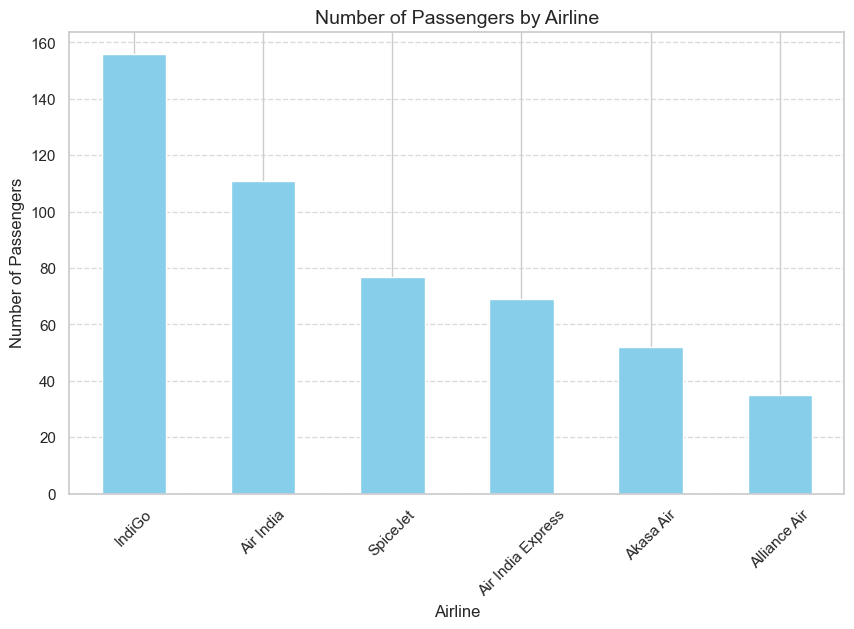

In [97]:
plt.figure(figsize=(10,6))
df["Airline"].value_counts().plot(kind="bar", color="skyblue")
plt.title("Number of Passengers by Airline", fontsize=14)
plt.xlabel("Airline", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

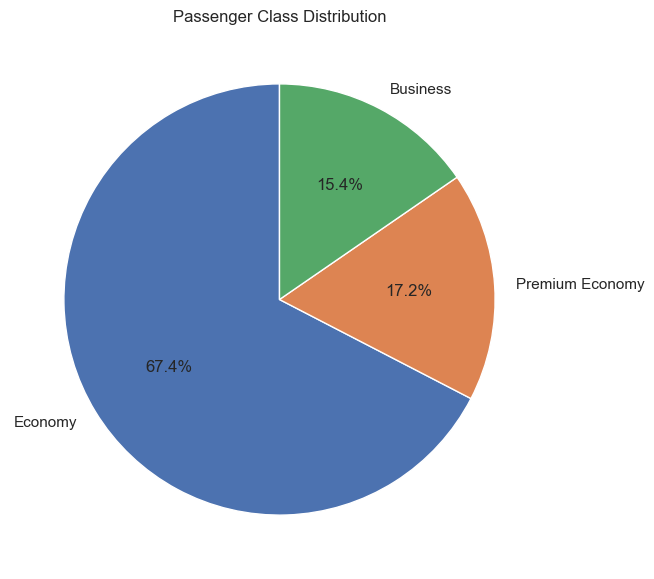

In [98]:
plt.figure(figsize=(7,7))

df["Class"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Passenger Class Distribution")
plt.ylabel("")
plt.show()

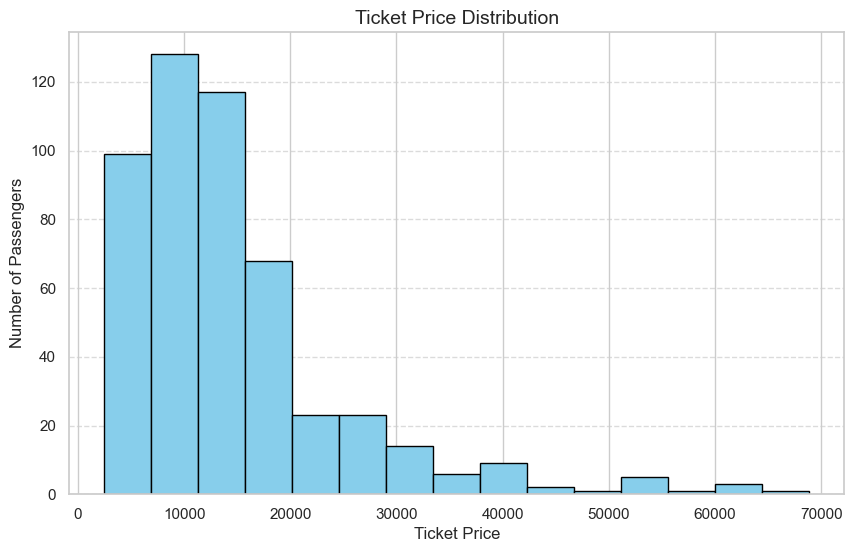

In [99]:
plt.figure(figsize=(10, 6))

plt.hist(df["Ticket_Price"],
         bins=15,
         color="skyblue",
         edgecolor="black")

plt.title("Ticket Price Distribution", fontsize=14)
plt.xlabel("Ticket Price", fontsize=12)
plt.ylabel("Number of Passengers", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

C:\Users\pugal\AppData\Local\Temp\ipykernel_13464\571215937.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


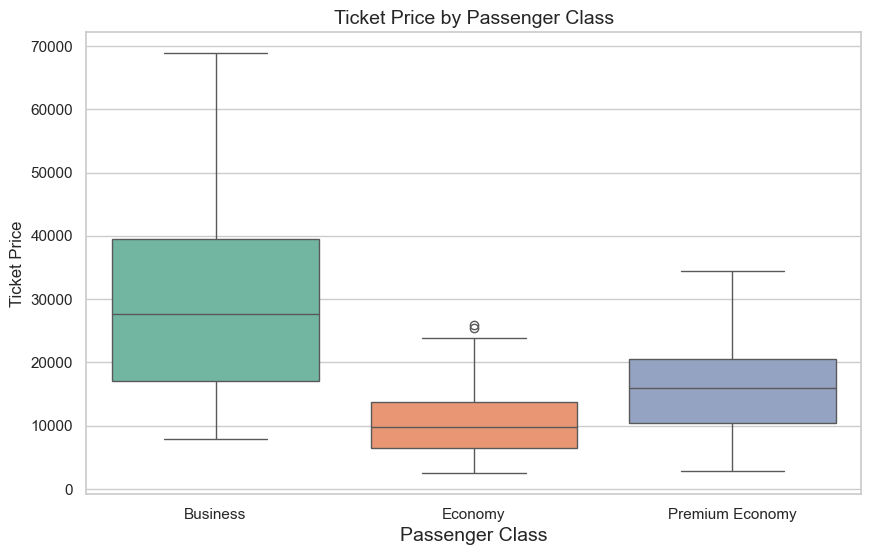

In [100]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Class",
    y="Ticket_Price",
    data=df,
    palette="Set2"
)

plt.title("Ticket Price by Passenger Class", fontsize=14)
plt.xlabel("Passenger Class", fontsize=14)
plt.ylabel("Ticket Price", fontsize=12)
plt.show()

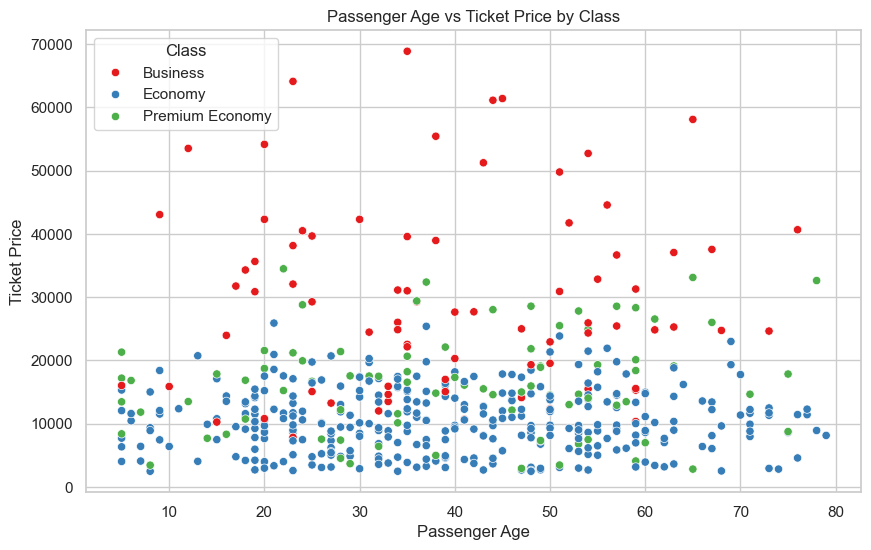

In [101]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="Passenger_Age",
    y="Ticket_Price",
    hue="Class",
    data=df,
    palette="Set1"
)

plt.title("Passenger Age vs Ticket Price by Class")
plt.xlabel("Passenger Age")
plt.ylabel("Ticket Price")
plt.show()

In [102]:
numeric_data = df.select_dtypes(include=["int64", "float64"])

numeric_data.head()

,Passenger_Age,Ticket_Price,Flight_Duration,Departure_Delay,Arrival_Delay
0,27,13270,69.0,4.0,2.0
1,57,36670,193.0,2.0,14.0
2,34,17470,200.0,9.0,1.0
3,31,10020,115.0,6.0,4.0
4,45,17860,195.0,8.0,9.0


In [103]:
correlation = numeric_data.corr()

print(correlation)

                 Passenger_Age  Ticket_Price  Flight_Duration  \
Passenger_Age         1.000000      0.027278         0.034863   
Ticket_Price          0.027278      1.000000         0.636392   
Flight_Duration       0.034863      0.636392         1.000000   
Departure_Delay       0.039519      0.013238         0.034237   
Arrival_Delay         0.035239      0.017107         0.072124   

                 Departure_Delay  Arrival_Delay  
Passenger_Age           0.039519       0.035239  
Ticket_Price            0.013238       0.017107  
Flight_Duration         0.034237       0.072124  
Departure_Delay         1.000000       0.973882  
Arrival_Delay           0.973882       1.000000  


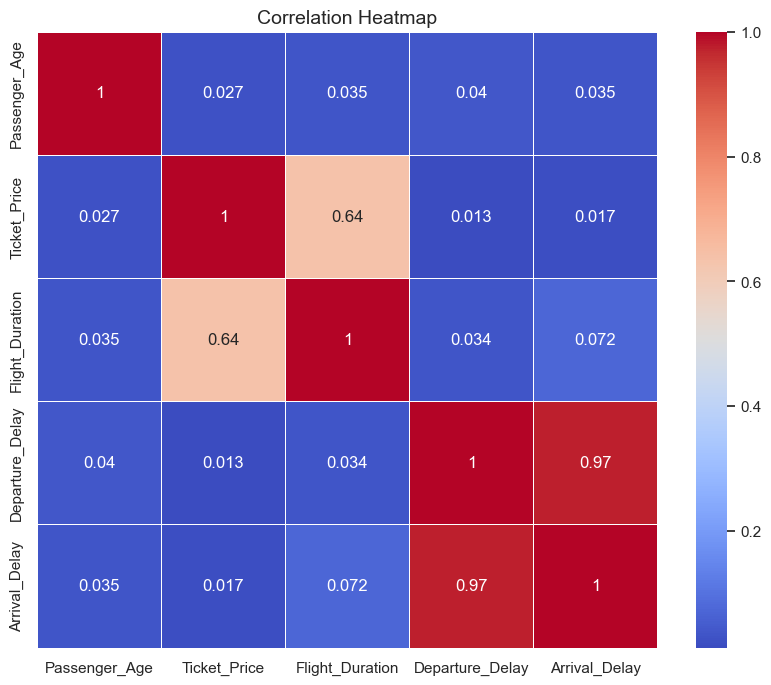

In [104]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=14)
plt.show()

In [105]:
print("=" * 50)
print(" FLIGHT PASSENGER DATA ANALYSIS SUMMARY ")
print("=" * 50)

print("Total Passengers :", len(df))

print("Average Passenger Age :", round(df["Passenger_Age"].mean(), 2))

print("Average Ticket Price :", round(df["Ticket_Price"].mean(), 2))

print("Highest Ticket Price :", df["Ticket_Price"].max())

print("Lowest Ticket Price :", df["Ticket_Price"].min())

print("Most Popular Airline :",
      df["Airline"].value_counts().idxmax())

print("Most Common Class :",
      df["Class"].value_counts().idxmax())

print("Average Flight Duration :",
      round(df["Flight_Duration"].mean(), 2))

print("Average Departure Delay :",
      round(df["Departure_Delay"].mean(), 2))

print("Average Arrival Delay :",
      round(df["Arrival_Delay"].mean(), 2))

print("Total Revenue : ₹",
      round(df["Ticket_Price"].sum(), 2))

print("=" * 50)

 FLIGHT PASSENGER DATA ANALYSIS SUMMARY 
Total Passengers : 500
Average Passenger Age : 39.35
Average Ticket Price : 14440.66
Highest Ticket Price : 68860
Lowest Ticket Price : 2500
Most Popular Airline : IndiGo
Most Common Class : Economy
Average Flight Duration : 124.49
Average Departure Delay : 28.05
Average Arrival Delay : 32.31
Total Revenue : ₹ 7220330


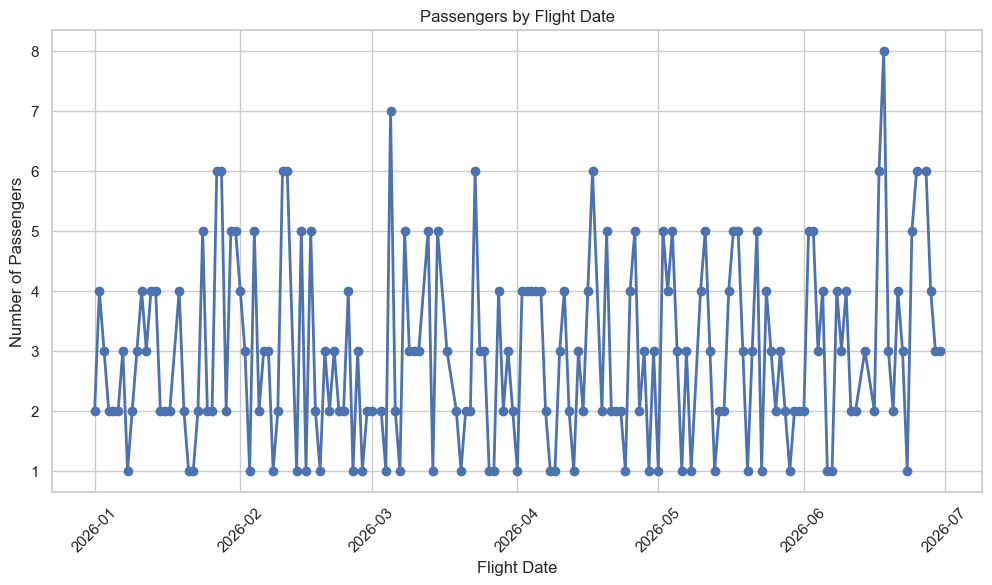

In [106]:
df["Flight_Date"] = pd.to_datetime(df["Flight_Date"])

daily_passengers = df.groupby("Flight_Date").size()

plt.figure(figsize=(12,6))

plt.plot(
    daily_passengers.index,
    daily_passengers.values,
    marker="o",
    linewidth=2
)

plt.title("Passengers by Flight Date")
plt.xlabel("Flight Date")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [107]:
top10 = df.nlargest(10, "Ticket_Price")

print(top10[[
    "Passenger_Name",
    "Airline",
    "Ticket_Price"
]])

       Passenger_Name    Airline  Ticket_Price
301        Yash Singh   SpiceJet         68860
133    Mahesh Chauhan   SpiceJet         64100
352    Komal Malhotra  Air India         61390
375    Mahesh Chauhan     IndiGo         61120
395    Preethi Kapoor     IndiGo         58090
100     Suman Chauhan  Air India         55430
326    Vandana Mishra  Akasa Air         54150
66   Madhavi Krishnan  Akasa Air         53510
221       Nisha Singh   SpiceJet         52720
245     Charu Chauhan     IndiGo         51240


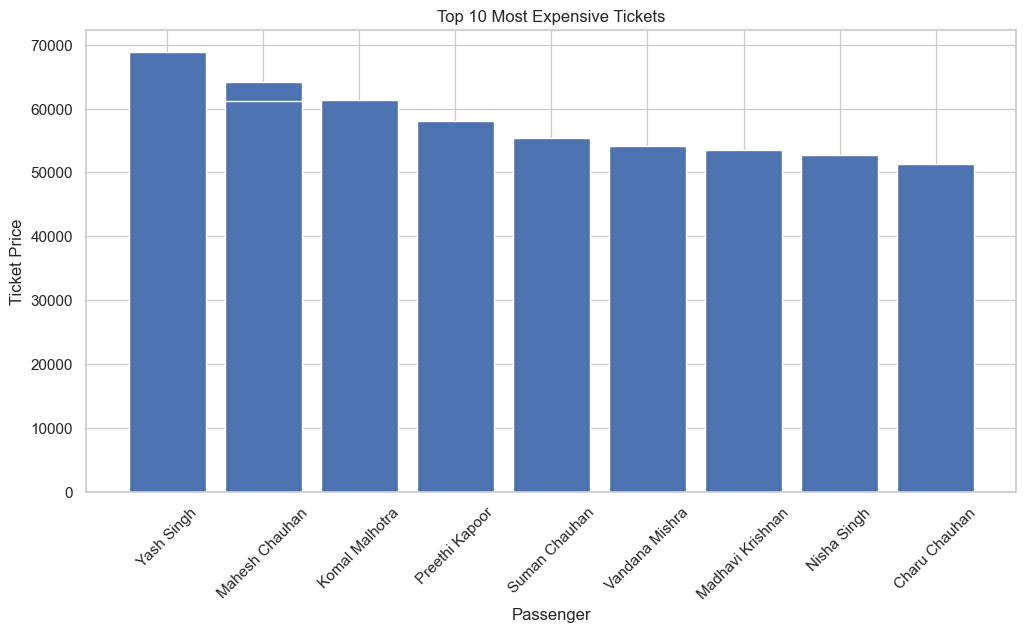

In [108]:
plt.figure(figsize=(12,6))

plt.bar(
    top10["Passenger_Name"],
    top10["Ticket_Price"]
)

plt.title("Top 10 Most Expensive Tickets")
plt.xlabel("Passenger")
plt.ylabel("Ticket Price")
plt.xticks(rotation=45)
plt.show()

In [109]:
print(df.columns.tolist())

['Passenger_ID', 'Passenger_Name', 'Passenger_Age', 'Gender', 'Airline', 'Flight_Number', 'Flight_Date', 'Start_City', 'Destination_City', 'Scheduled_Departure', 'Actual_Departure', 'Scheduled_Arrival', 'Actual_Arrival', 'Ticket_Price', 'Class', 'Seat_Number', 'Flight_Duration', 'Departure_Delay', 'Arrival_Delay', 'Price_Category', 'Age_Group']


In [110]:
df["Route"] = (
    df["Start_City"] +
    " → " +
    df["Destination_City"]
)

popular_routes = df["Route"].value_counts().head(10)

print(popular_routes)

Route
Ahmedabad → Mangalore         4
Kochi → Varanasi              3
Madurai → Mumbai              3
Chandigarh → Coimbatore       3
Lucknow → Chennai             3
Ahmedabad → Srinagar          3
Tiruchirappalli → Srinagar    3
Hyderabad → Jaipur            3
Hyderabad → Amritsar          3
Bengaluru → Surat             3
Name: count, dtype: int64


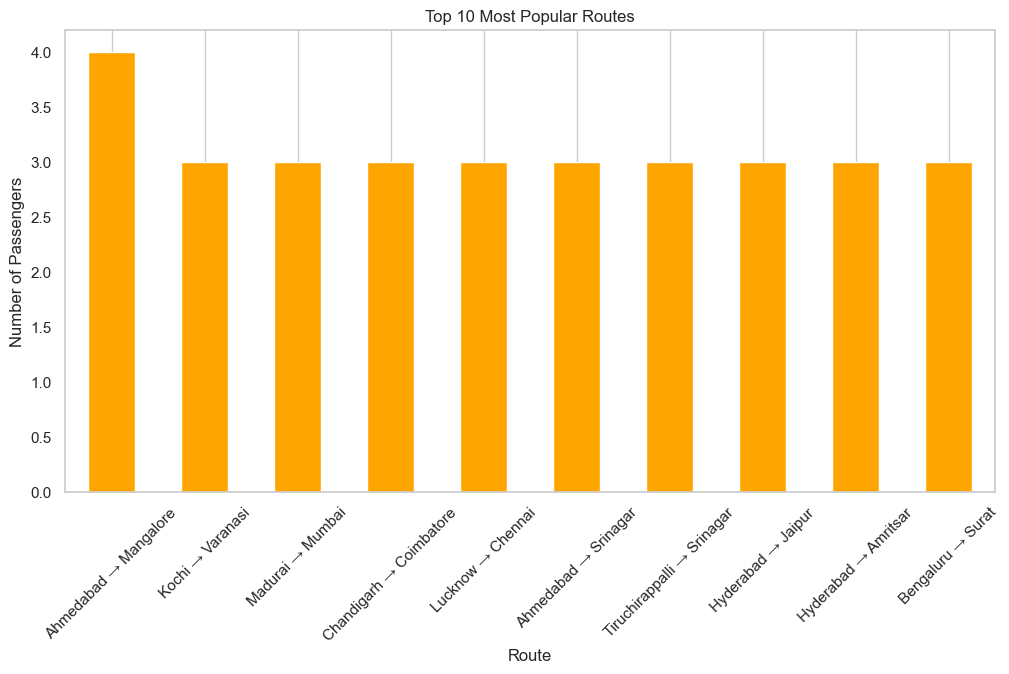

In [111]:
plt.figure(figsize=(12,6))

popular_routes.plot(
    kind="bar",
    color="orange"
)

plt.title("Top 10 Most Popular Routes")
plt.xlabel("Route")
plt.ylabel("Number of Passengers")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [112]:
avg_ticket = (
    df.groupby("Airline")["Ticket_Price"]
      .mean()
      .sort_values(ascending=False)
)

print(avg_ticket)

Airline
SpiceJet             15901.688312
Akasa Air            15176.923077
IndiGo               14305.576923
Air India            13864.684685
Alliance Air         13858.285714
Air India Express    13782.753623
Name: Ticket_Price, dtype: float64


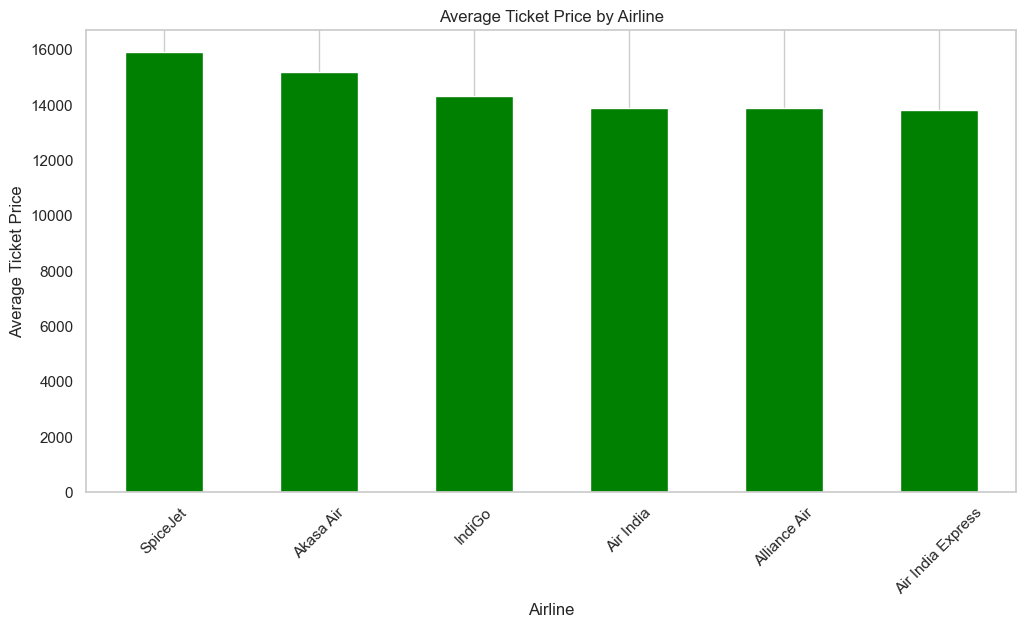

In [113]:
plt.figure(figsize=(12,6))

avg_ticket.plot(
    kind="bar",
    color="green"
)

plt.title("Average Ticket Price by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Ticket Price")
plt.xticks(rotation=45)
plt.grid(axis="y")
plt.show()

In [114]:
df["Month"] = df["Flight_Date"].dt.month_name()

month_order = [
    "January","February","March","April",
    "May","June","July","August",
    "September","October","November","December"
]

monthly = (
    df["Month"]
      .value_counts()
      .reindex(month_order)
)

print(monthly)

Month
January      88.0
February     74.0
March        75.0
April        82.0
May          86.0
June         95.0
July          NaN
August        NaN
September     NaN
October       NaN
November      NaN
December      NaN
Name: count, dtype: float64


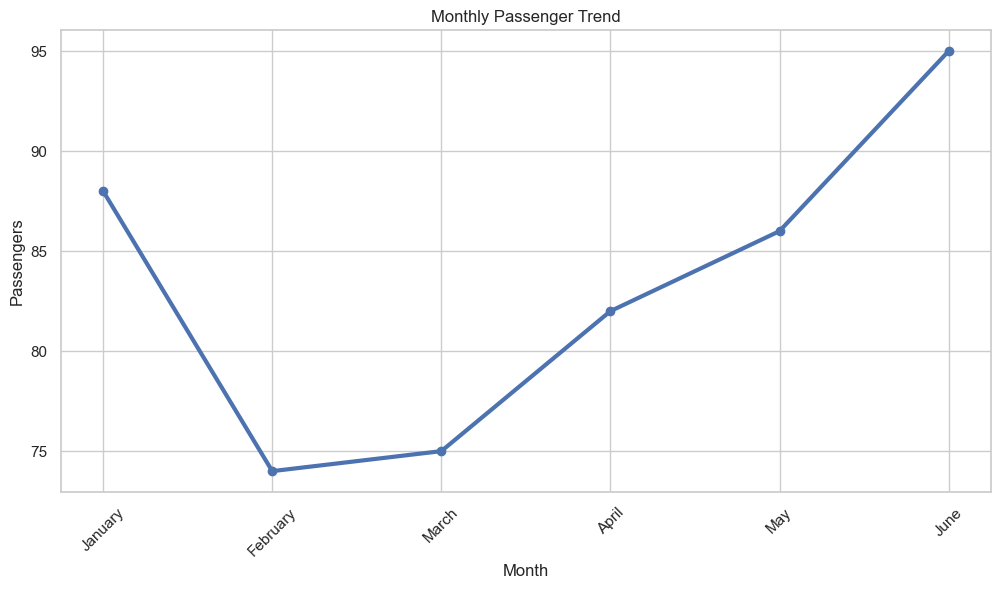

In [115]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly.index,
    monthly.values,
    marker="o",
    linewidth=3
)

plt.title("Monthly Passenger Trend")
plt.xlabel("Month")
plt.ylabel("Passengers")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

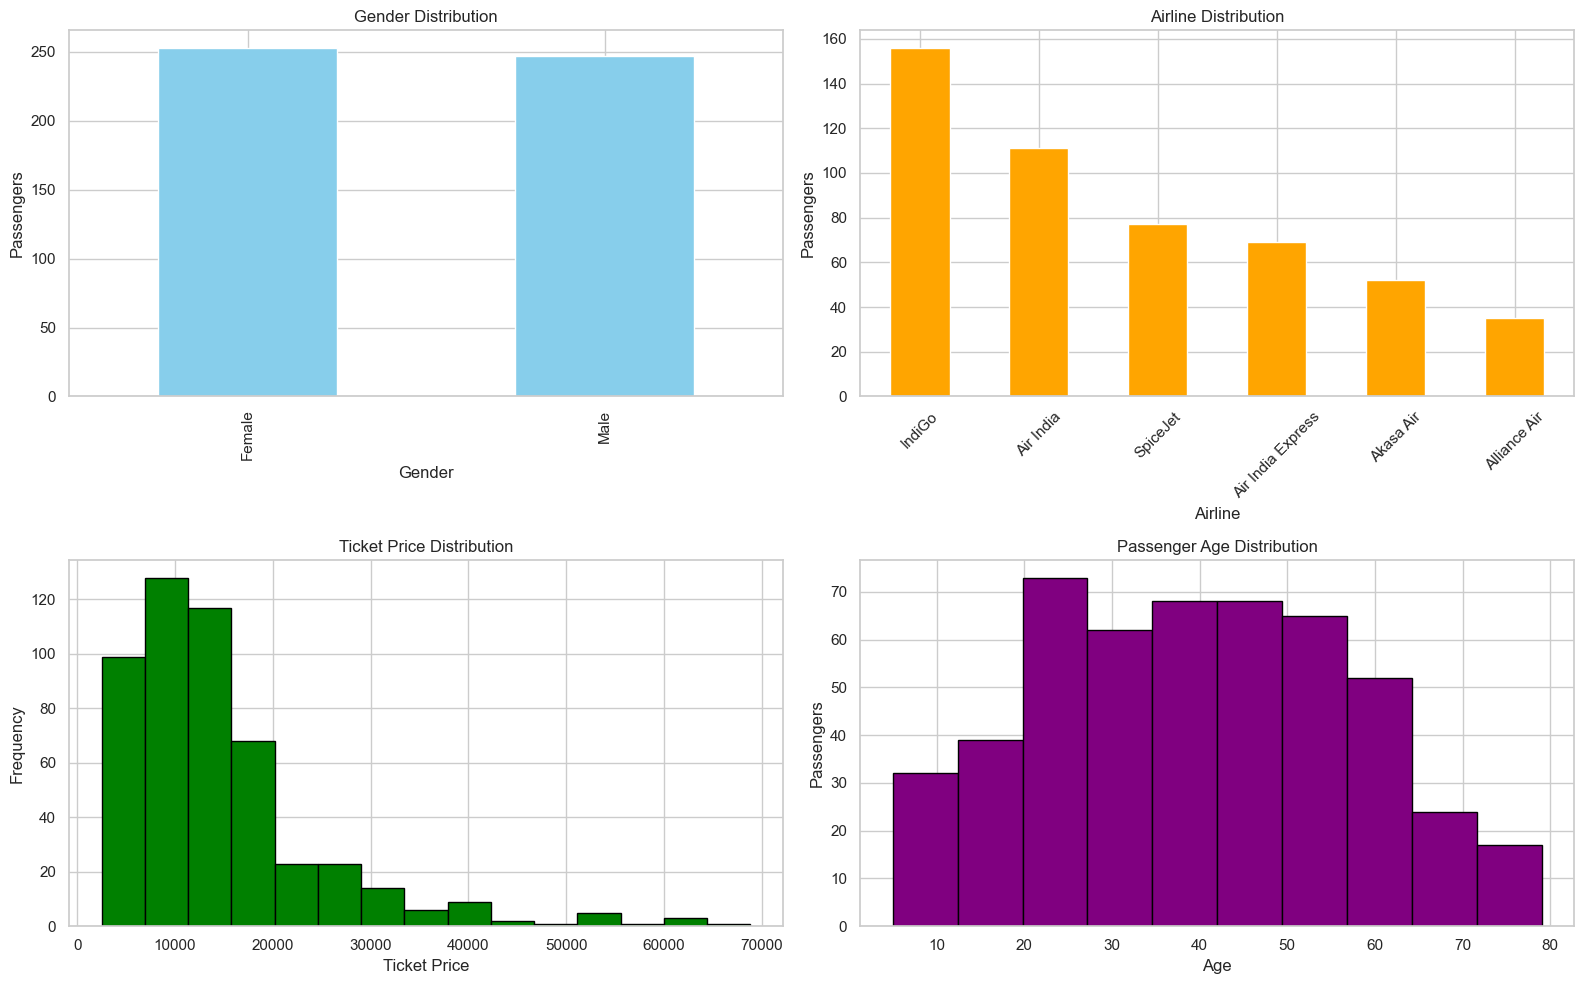

In [116]:
plt.figure(figsize=(16, 10))

plt.subplot(2, 2, 1)

df["Gender"].value_counts().plot(kind="bar", color="skyblue")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Passengers")

plt.subplot(2, 2, 2)

df["Airline"].value_counts().plot(kind="bar", color="orange")

plt.title("Airline Distribution")
plt.xlabel("Airline")
plt.ylabel("Passengers")
plt.xticks(rotation=45)

plt.subplot(2, 2, 3)

plt.hist(df["Ticket_Price"],
         bins=15,
         color="green",
         edgecolor="black")

plt.title("Ticket Price Distribution")
plt.xlabel("Ticket Price")
plt.ylabel("Frequency")

plt.subplot(2, 2, 4)

plt.hist(df["Passenger_Age"],
         bins=10,
         color="purple",
         edgecolor="black")

plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Passengers")

plt.tight_layout()

plt.show()